In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from PyGRF import PyGRF


# Set file paths
CSV_PATH = r"C:\Users\Azucar\Desktop\Master Thesis\Data\gwrf_6perceptions_14POIs.csv"
OUT_DIR = r"C:\Users\Azucar\Desktop\Master Thesis\Data"

# Define variables
TARGET = "log_total_count"
ID_COL = "point_id"
COORD_COLS = ["longitude", "latitude"]

PREDICTORS = [
    "depression_score",
    "aesthetic_score",
    "safety_score",
    "vitality_score",
    "boringness_score",
    "wealth_score",
    "road_length",
    "ghs_population",
    "poi_catering_density",
    "poi_shopping_density",
    "poi_public_facility_density",
    "poi_health_density",
    "poi_leisure_density",
    "poi_tourism_density",
    "poi_transit_density",
    "poi_catering_dist",
    "poi_shopping_dist",
    "poi_public_facility_dist",
    "poi_health_dist",
    "poi_leisure_dist",
    "poi_tourism_dist",
    "poi_transit_dist"]

# PyGRF settings
TEST_SIZE = 0.2
RANDOM_STATE = 42
LOCAL_WEIGHT = 0.7
N_ESTIMATORS = 200
MAX_FEATURES = 4
BAND_WIDTH = 120

# Define functions
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def print_metrics(name, y_true, y_pred):
    print(f"{name}")
    print(f"  R²   : {r2_score(y_true, y_pred):.4f}")
    print(f"  RMSE : {rmse(y_true, y_pred):.4f}")
    print(f"  MAE  : {mean_absolute_error(y_true, y_pred):.4f}")

    
# Load csv file
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV file not found:\n{CSV_PATH}")

df = pd.read_csv(CSV_PATH, encoding="latin1")
print(f"Loaded dataset: {CSV_PATH}")
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")

Loaded dataset: C:\Users\Azucar\Desktop\Master Thesis\Data\gwrf_6perceptions_14POIs.csv
Rows: 9893, Columns: 35


In [2]:
# Check missing columns
required_cols = [ID_COL] + COORD_COLS + [TARGET] + PREDICTORS
missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

data = df[required_cols].copy()

# Drop missing values if necessary
before_drop = len(data)
data = data.dropna().reset_index(drop=True)
after_drop = len(data)

print(f"\nRows before drop: {before_drop}")
print(f"Rows after drop: {after_drop}")
print(f"Rows removed: {before_drop - after_drop}")


Rows before drop: 9893
Rows after drop: 9893
Rows removed: 0


In [3]:
# Extract variables from the table
X = data[PREDICTORS].copy()
y = data[TARGET].copy()
coords = data[COORD_COLS].to_numpy()
point_ids = data[ID_COL].copy()


# Split training and testing data
X_train, X_test, y_train, y_test, coords_train, coords_test, id_train, id_test = train_test_split(
    X,
    y,
    coords,
    point_ids,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE)

print(f"\nTrain size: {len(X_train)}")
print(f"Test size : {len(X_test)}")


Train size: 7914
Test size : 1979


In [4]:
# Fit GWRF
print("\nFitting GWRF model...")

model = PyGRF.PyGRFBuilder(
    n_estimators=N_ESTIMATORS,
    max_features=MAX_FEATURES,
    band_width=BAND_WIDTH,
    train_weighted=True,
    predict_weighted=True,
    bootstrap=False,
    resampled=True,
    random_state=RANDOM_STATE)

model.fit(X_train, y_train, coords_train)

pred_combined, pred_global, pred_local = model.predict(
    X_test,
    coords_test,
    local_weight=LOCAL_WEIGHT)

pred_combined = np.asarray(pred_combined)
pred_global = np.asarray(pred_global)
pred_local = np.asarray(pred_local)
y_test_array = np.asarray(y_test)


# Evaluate model performance
print("\n=== GWRF TEST PERFORMANCE ===")
print(f"Dependent variable: {TARGET}")
print_metrics("Combined model:", y_test_array, pred_combined)
print_metrics("Global part   :", y_test_array, pred_global)
print_metrics("Local part    :", y_test_array, pred_local)


Fitting GWRF model...

=== GWRF TEST PERFORMANCE ===
Dependent variable: log_total_count
Combined model:
  R²   : 0.9471
  RMSE : 0.4681
  MAE  : 0.3363
Global part   :
  R²   : 0.8744
  RMSE : 0.7209
  MAE  : 0.5122
Local part    :
  R²   : 0.9570
  RMSE : 0.4221
  MAE  : 0.2957



Saved test predictions to:
C:\Users\Azucar\Desktop\Master Thesis\Data\gwrf_log_total_count_test_predictions.csv


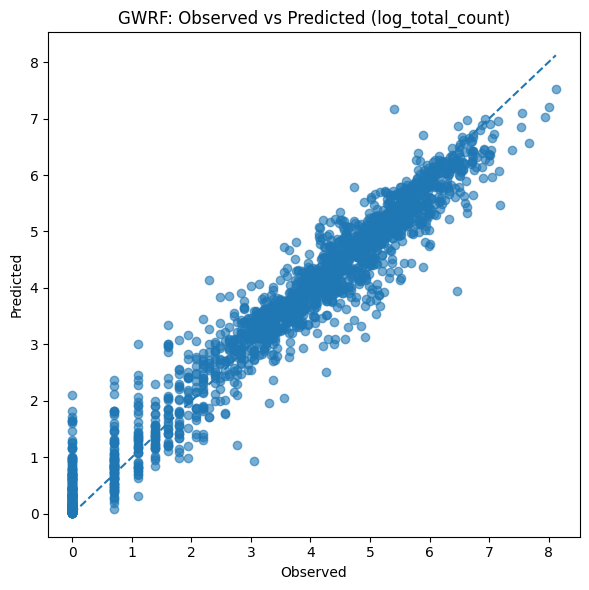

In [5]:
# Save test predictions
pred_df = pd.DataFrame({
    ID_COL: id_test.values,
    "observed": y_test.values,
    "pred_combined": pred_combined,
    "pred_global": pred_global,
    "pred_local": pred_local})

pred_df["residual_combined"] = pred_df["observed"] - pred_df["pred_combined"]

out_pred = os.path.join(OUT_DIR, f"gwrf_{TARGET}_test_predictions.csv")
pred_df.to_csv(out_pred, index=False)

print(f"\nSaved test predictions to:\n{out_pred}")


# Plot observations v.s. predictions
plt.figure(figsize=(6, 6))
plt.scatter(y_test_array, pred_combined, alpha=0.6)

mn = min(y_test_array.min(), pred_combined.min())
mx = max(y_test_array.max(), pred_combined.max())
plt.plot([mn, mx], [mn, mx], linestyle="--")

plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title(f"GWRF: Observed vs Predicted ({TARGET})")
plt.tight_layout()
plt.show()

In [6]:
# SHAP analysis
print("\nComputing SHAP values...")

# Convert to numpy array
X_test_np = X_test.to_numpy()

# Use the RF model from PyGRF
rf_model = model.global_model
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_np)

# Convert to dataframe
shap_df = pd.DataFrame(
    shap_values,
    columns=PREDICTORS)
shap_df[ID_COL] = id_test.values

# Save SHAP values
OUT_SHAP = os.path.join(
    OUT_DIR,
    f"gwrf_{TARGET}_shap_values.csv")
shap_df.to_csv(OUT_SHAP, index=False)
print(f"\nSaved SHAP values to:\n{OUT_SHAP}")


Computing SHAP values...

Saved SHAP values to:
C:\Users\Azucar\Desktop\Master Thesis\Data\gwrf_log_total_count_shap_values.csv


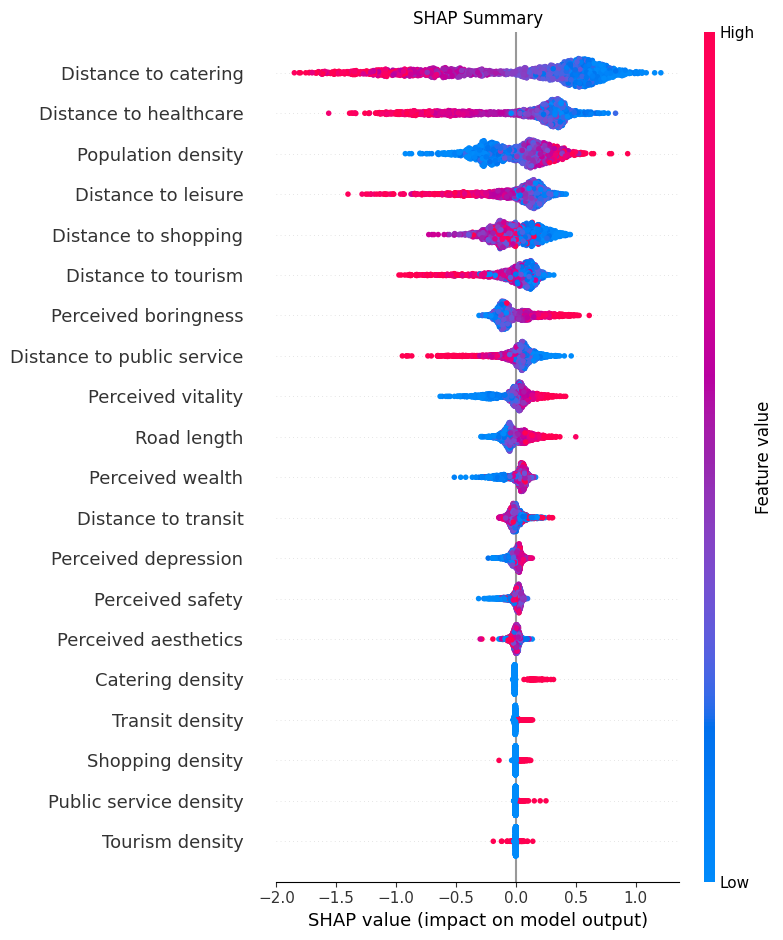

In [7]:
# SHAP summary
# Rename columns for visualization
nice_labels = {
    # Perception variables
    "depression_score": "Perceived depression",
    "aesthetic_score": "Perceived aesthetics",
    "safety_score": "Perceived safety",
    "vitality_score": "Perceived vitality",
    "wealth_score": "Perceived wealth",
    "boringness_score": "Perceived boringness",
    
    # Built environment
    "road_length": "Road length",
    "ghs_population": "Population density",

    # Density-based POI
    "poi_catering_density": "Catering density",
    "poi_shopping_density": "Shopping density",
    "poi_public_facility_density": "Public service density",
    "poi_health_density": "Healthcare density",
    "poi_leisure_density": "Leisure density",
    "poi_tourism_density": "Tourism density",
    "poi_transit_density": "Transit density",

    # Distance-based POI
    "poi_catering_dist": "Distance to catering",
    "poi_shopping_dist": "Distance to shopping",
    "poi_public_facility_dist": "Distance to public service",
    "poi_health_dist": "Distance to healthcare",
    "poi_leisure_dist": "Distance to leisure",
    "poi_tourism_dist": "Distance to tourism",
    "poi_transit_dist": "Distance to transit"}

X_test_named = X_test.rename(columns=nice_labels)
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_named,
    show=False)
plt.title(f"SHAP Summary")
plt.tight_layout()
plt.show()


Computing feature importance...

Saved feature importance table to:
C:\Users\Azucar\Desktop\Master Thesis\Data\gwrf_log_total_count_feature_importance.csv
                        feature  importance               feature_label
0             poi_catering_dist    0.227330        Distance to catering
1               poi_health_dist    0.142775      Distance to healthcare
2                ghs_population    0.080118          Population density
3              poi_leisure_dist    0.072313         Distance to leisure
4              poi_tourism_dist    0.072286         Distance to tourism
5             poi_shopping_dist    0.068740        Distance to shopping
6      poi_public_facility_dist    0.061467  Distance to public service
7                vitality_score    0.049801          Perceived vitality
8              boringness_score    0.046877        Perceived boringness
9                  wealth_score    0.035509            Perceived wealth
10                  road_length    0.030465         

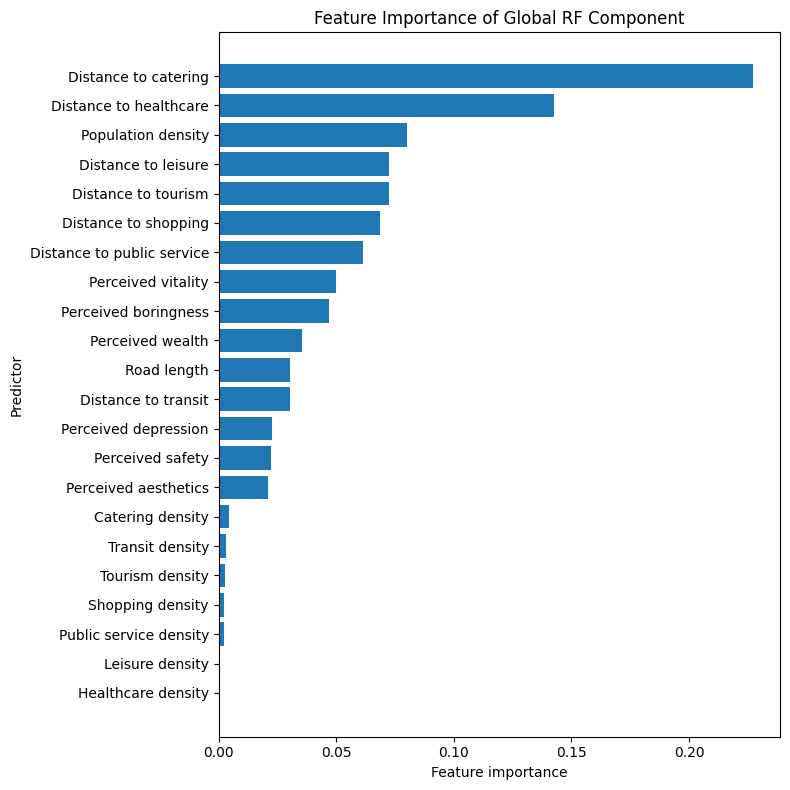

In [8]:
print("\nComputing feature importance...")

# Extract feature importance from the global RF model
rf_model = model.global_model
feature_importance = rf_model.feature_importances_

# Create dataframe
fi_df = pd.DataFrame({
    "feature": PREDICTORS,
    "importance": feature_importance})

# Add labels
fi_df["feature_label"] = fi_df["feature"].map(nice_labels)
fi_df["feature_label"] = fi_df["feature_label"].fillna(fi_df["feature"])

# Sort by importance
fi_df = fi_df.sort_values("importance", ascending=False).reset_index(drop=True)

# Save feature importance table
OUT_FI = os.path.join(
    OUT_DIR,
    f"gwrf_{TARGET}_feature_importance.csv")
fi_df.to_csv(OUT_FI, index=False)
print(f"\nSaved feature importance table to:\n{OUT_FI}")
print(fi_df)

# Create feature importance plot
fi_plot = fi_df.sort_values("importance", ascending=True)
plt.figure(figsize=(8, 8))
plt.barh(
    fi_plot["feature_label"],
    fi_plot["importance"])
plt.xlabel("Feature importance")
plt.ylabel("Predictor")
plt.title(f"Feature Importance of Global RF Component")
plt.tight_layout()

# Save figure
OUT_FI_PLOT = os.path.join(
    OUT_DIR,
    f"gwrf_{TARGET}_feature_importance.png")
plt.savefig(OUT_FI_PLOT, dpi=300, bbox_inches="tight")
print(f"\nSaved feature importance plot to:\n{OUT_FI_PLOT}")
plt.show()